# 🌸 Modul 2 — Praktikum Fondasi Probabilitas untuk ML

### Studi Kasus: Iris Species Dataset (Kaggle)

**Mata Kuliah:** Statistika & Probabilitas (TIF1501)  
**Program Studi:** Teknik Informatika (55201) · FTI · Uniska MAB Banjarmasin  
**Semester:** 5 · 3 SKS

---

## 🎯 Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, Anda akan mampu:

1. **Mendefinisikan** ruang sampel dalam konteks Train/Test Split dan K-Fold Cross-Validation.
2. **Menerapkan** aksioma Kolmogorov dalam perhitungan peluang.
3. **Menggunakan** operasi himpunan (irisan, gabungan, komplemen) dengan NumPy.
4. **Menerapkan** permutasi dan kombinasi untuk hyperparameter grid search.

---

## 📋 Alur Notebook

| Bagian | Isi | Waktu |
|--------|-----|-------|
| **A** | Setup & Load Iris dari Kaggle | 10 menit |
| **B** | Ruang Sampel: Train/Test Split | 15 menit |
| **C** | Ruang Sampel: K-Fold Cross-Validation | 15 menit |
| **D** | Aksioma Kolmogorov (Perhitungan) | 15 menit |
| **E** | Operasi Himpunan dengan NumPy | 15 menit |
| **F** | Kombinatorik Grid Search — LATIHAN UTAMA | 15 menit |
| **G** | Refleksi & Submit ke GitHub | 5 menit |

**Total: ± 90 menit**

---

## 💡 Kenapa Iris Species?

Dataset Iris (Ronald Fisher, 1936) adalah dataset klasik data science di Kaggle. Berisi 150 sampel bunga Iris dari 3 spesies (masing-masing 50 sampel). **Sempurna untuk Modul 2** karena:

- ✅ **Balanced 50-50-50** → P(setosa) = P(versicolor) = P(virginica) = 1/3, sempurna untuk aksioma Kolmogorov.
- ✅ **Kecil (150 baris)** → visualisasi K-Fold dan sampling bisa jelas terlihat.
- ✅ **3 kelas nominal** → ruang sampel S = {setosa, versicolor, virginica} kelihatan konkret.
- ✅ **4 fitur numerik** → cukup kaya untuk feature selection dengan set operations.
- ✅ **Kompatibel dengan K-NN** → hyperparameter grid search mudah dipahami.


---

# 🔧 A. Setup & Load Dataset Iris

## A.1 Import Library


In [ ]:
# Library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: alat utama Machine Learning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# itertools untuk kombinatorik manual
from itertools import product, permutations, combinations
from math import factorial, comb, perm

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Semua library berhasil di-import!")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")


✅ Semua library berhasil di-import!
pandas       : 2.2.3
numpy        : 2.1.3


## A.2 Load Iris dari URL Publik (Kaggle-style)


In [ ]:
# Load Iris dataset — dari URL publik yang sama dengan versi Kaggle
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Tampilkan 5 baris pertama
print(f"Ukuran dataset: {df.shape}")
df.head()
#df.info()


Ukuran dataset: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Statistik dasar
print("Distribusi kelas:")
print(df['species'].value_counts())
print("\nStatistik numerik:")
df.describe().round(2)


Distribusi kelas:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistik numerik:


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


> 📊 Konfirmasi: 150 baris, 3 kelas, masing-masing 50 sampel — dataset **perfectly balanced**.


---

# 🎲 B. Ruang Sampel dalam Train/Test Split

## B.1 Definisi Ruang Sampel

**Ruang Sampel Eksperimen "Train/Test Split":**
$$S = \{ \text{semua kemungkinan pemisahan 120 dari 150 baris untuk train} \}$$

Ukuran ruang sampel:
$$|S| = \binom{150}{30}$$


In [ ]:
# Hitung ukuran ruang sampel eksperimen train/test split
from math import comb

N = 150       # total baris
test_size = 30  # 20% test

ruang_sampel_size = comb(N, test_size)
print(f"|S| = C(150, 30) = {ruang_sampel_size:,}")
print(f"Dalam notasi ilmiah: {ruang_sampel_size:.3e}")
print(f"\nArtinya: ada {ruang_sampel_size:,} kemungkinan cara memisahkan 150 baris menjadi 120 train + 30 test.")


|S| = C(150, 30) = 32,198,785,340,494,567,031,466,236,484,400
Dalam notasi ilmiah: 3.220e+31

Artinya: ada 32,198,785,340,494,567,031,466,236,484,400 kemungkinan cara memisahkan 150 baris menjadi 120 train + 30 test.


> 🤯 Angka yang sangat besar! Inilah kenapa `random_state` penting — untuk menetapkan satu titik spesifik di ruang sampel yang bisa direproduksi.


## B.2 Praktik Train/Test Split


In [ ]:
# Pisahkan fitur (X) dan label (y)
X = df.drop('species', axis=1)
y = df['species']

# Split dengan stratifikasi (menjaga proporsi kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # penting: menjaga proporsi kelas
)

print(f"Ukuran TRAIN : {X_train.shape[0]} baris")
print(f"Ukuran TEST  : {X_test.shape[0]} baris")

print("\nProporsi kelas di TRAIN:")
print((y_train.value_counts(normalize=True) * 100).round(1))
print("\nProporsi kelas di TEST:")
print((y_test.value_counts(normalize=True) * 100).round(1))


Ukuran TRAIN : 120 baris
Ukuran TEST  : 30 baris

Proporsi kelas di TRAIN:
species
setosa        33.3
virginica     33.3
versicolor    33.3
Name: proportion, dtype: float64

Proporsi kelas di TEST:
species
setosa        33.3
virginica     33.3
versicolor    33.3
Name: proportion, dtype: float64


> ✅ Karena kita pakai `stratify=y`, proporsi kelas di train dan test sama persis (33.3% masing-masing).


## B.3 Eksperimen: Banyak Kali Split dengan random_state Berbeda

Setiap `random_state` mengambil satu titik berbeda dari ruang sampel. Mari kita lihat efeknya:


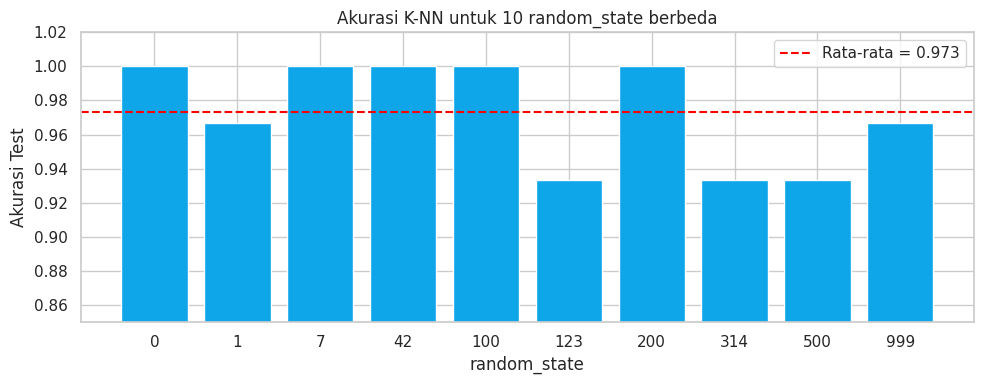

Akurasi min : 0.933
Akurasi max : 1.000
Std deviasi : 0.029


In [ ]:
# Coba 10 random_state berbeda, cek akurasi baseline model
akurasi_per_rs = []
random_states = [0, 1, 7, 42, 100, 123, 200, 314, 500, 999]

for rs in random_states:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=rs)
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_tr, y_tr)
    acc = model.score(X_te, y_te)
    akurasi_per_rs.append(acc)

# Visualisasi
plt.figure(figsize=(10, 4))
plt.bar([str(rs) for rs in random_states], akurasi_per_rs, color='#0EA5E9')
plt.axhline(np.mean(akurasi_per_rs), color='red', ls='--',
            label=f'Rata-rata = {np.mean(akurasi_per_rs):.3f}')
plt.title('Akurasi K-NN untuk 10 random_state berbeda')
plt.xlabel('random_state')
plt.ylabel('Akurasi Test')
plt.ylim(0.85, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Akurasi min : {min(akurasi_per_rs):.3f}")
print(f"Akurasi max : {max(akurasi_per_rs):.3f}")
print(f"Std deviasi : {np.std(akurasi_per_rs):.3f}")


> 💡 **Insight:** Meskipun modelnya sama, akurasi berbeda-beda tergantung split. Inilah kenapa satu kali split tidak cukup — kita butuh K-Fold CV.


---

# 🔄 C. Ruang Sampel dalam K-Fold Cross-Validation

## C.1 Konsep 5-Fold CV

Kita akan bandingkan 3 skema:
1. **KFold biasa** — pembagian random tanpa memperhatikan kelas
2. **StratifiedKFold** — menjaga proporsi kelas di setiap fold
3. **Cross-validation** dengan model K-NN


In [ ]:
# 5-Fold CV biasa
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("K-Fold BIASA (tanpa stratifikasi):")
print("=" * 60)
for i, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    y_test_fold = y.iloc[test_idx]
    proporsi = y_test_fold.value_counts(normalize=True).sort_index()
    print(f"Fold {i}: test size = {len(test_idx):3d}, proporsi = {dict(proporsi.round(2))}")


K-Fold BIASA (tanpa stratifikasi):
Fold 1: test size =  30, proporsi = {'setosa': np.float64(0.33), 'versicolor': np.float64(0.3), 'virginica': np.float64(0.37)}
Fold 2: test size =  30, proporsi = {'setosa': np.float64(0.43), 'versicolor': np.float64(0.33), 'virginica': np.float64(0.23)}
Fold 3: test size =  30, proporsi = {'setosa': np.float64(0.4), 'versicolor': np.float64(0.33), 'virginica': np.float64(0.27)}
Fold 4: test size =  30, proporsi = {'setosa': np.float64(0.27), 'versicolor': np.float64(0.33), 'virginica': np.float64(0.4)}
Fold 5: test size =  30, proporsi = {'setosa': np.float64(0.23), 'versicolor': np.float64(0.37), 'virginica': np.float64(0.4)}


In [ ]:
# StratifiedKFold — proporsi kelas terjaga
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nStratified K-Fold (dengan stratifikasi):")
print("=" * 60)
for i, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    y_test_fold = y.iloc[test_idx]
    proporsi = y_test_fold.value_counts(normalize=True).sort_index()
    print(f"Fold {i}: test size = {len(test_idx):3d}, proporsi = {dict(proporsi.round(2))}")



Stratified K-Fold (dengan stratifikasi):
Fold 1: test size =  30, proporsi = {'setosa': np.float64(0.33), 'versicolor': np.float64(0.33), 'virginica': np.float64(0.33)}
Fold 2: test size =  30, proporsi = {'setosa': np.float64(0.33), 'versicolor': np.float64(0.33), 'virginica': np.float64(0.33)}
Fold 3: test size =  30, proporsi = {'setosa': np.float64(0.33), 'versicolor': np.float64(0.33), 'virginica': np.float64(0.33)}
Fold 4: test size =  30, proporsi = {'setosa': np.float64(0.33), 'versicolor': np.float64(0.33), 'virginica': np.float64(0.33)}
Fold 5: test size =  30, proporsi = {'setosa': np.float64(0.33), 'versicolor': np.float64(0.33), 'virginica': np.float64(0.33)}


> ✅ **Perhatikan:** Dengan StratifiedKFold, setiap fold punya proporsi 33% × 3 kelas yang konsisten. Dengan KFold biasa, ada variasi kecil karena random.


## C.2 Visualisasi Fold Assignment


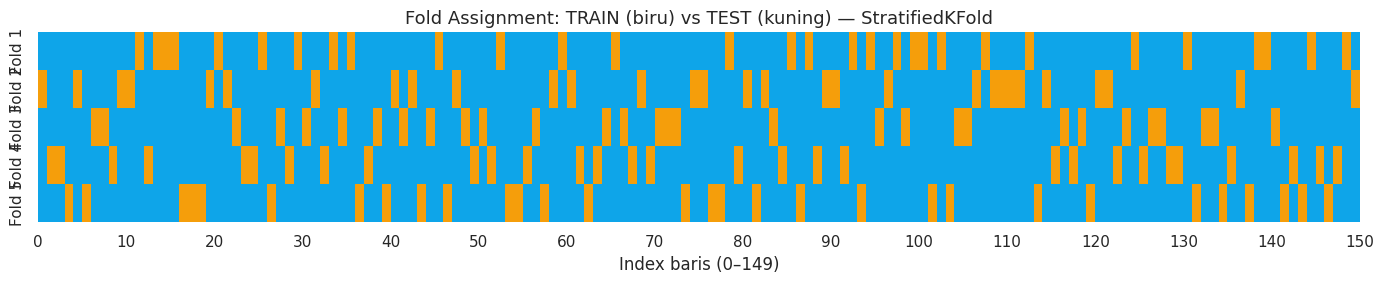

Total sel = 5 fold × 150 baris = 750
Setiap baris muncul di test EXACTLY sekali → cross-validation valid.


In [ ]:
# Buat matrix visualisasi fold assignment
fold_matrix = np.zeros((5, 150), dtype=int)

for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    fold_matrix[i, test_idx] = 1  # 1 = test, 0 = train

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(fold_matrix, cmap=['#0EA5E9', '#F59E0B'], cbar=False, ax=ax,
            yticklabels=[f'Fold {i+1}' for i in range(5)])
ax.set_title('Fold Assignment: TRAIN (biru) vs TEST (kuning) — StratifiedKFold', fontsize=13)
ax.set_xlabel('Index baris (0–149)')
ax.set_xticks(range(0, 151, 10))
ax.set_xticklabels(range(0, 151, 10), rotation=0)
plt.tight_layout()
plt.show()

print("Total sel = 5 fold × 150 baris = 750")
print("Setiap baris muncul di test EXACTLY sekali → cross-validation valid.")


## C.3 Cross-Validation Score dengan K-NN


In [ ]:
# Evaluasi model K-NN dengan 5-fold StratifiedCV
model = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print("Skor per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nRata-rata skor CV: {cv_scores.mean():.4f}")
print(f"Standar deviasi  : {cv_scores.std():.4f}")
print(f"95% CI           : [{cv_scores.mean() - 1.96 * cv_scores.std():.4f}, {cv_scores.mean() + 1.96 * cv_scores.std():.4f}]")


Skor per fold:
  Fold 1: 1.0000
  Fold 2: 0.9667
  Fold 3: 0.9333
  Fold 4: 1.0000
  Fold 5: 0.9333

Rata-rata skor CV: 0.9667
Standar deviasi  : 0.0298
95% CI           : [0.9082, 1.0251]


---

# 📐 D. Aksioma Kolmogorov: Perhitungan Empiris

## D.1 Tiga Aksioma Kolmogorov (Rekap)

| Aksioma | Rumus | Arti |
|---------|-------|------|
| **1. Non-negatif** | $P(A) \geq 0$ | Probabilitas ≥ 0 |
| **2. Normalisasi** | $P(S) = 1$ | $\sum P = 1$ |
| **3. Aditif** | $P(A \cup B) = P(A) + P(B)$ jika $A \cap B = \varnothing$ | Untuk kejadian saling lepas |

## D.2 Hitung Probabilitas Setiap Spesies


In [ ]:
# Hitung probabilitas empiris setiap kelas
N = len(df)
prob_spesies = df['species'].value_counts() / N

print("Probabilitas Empiris Setiap Spesies:")
print("-" * 40)
for spesies, prob in prob_spesies.items():
    print(f"  P({spesies:12s}) = {int(prob * N):3d} / {N} = {prob:.4f}")

# Verifikasi aksioma 1: semua P ≥ 0
aksioma_1 = all(p >= 0 for p in prob_spesies)
print(f"\n✓ Aksioma 1 (P ≥ 0): {aksioma_1}")

# Verifikasi aksioma 2: sum = 1
total = prob_spesies.sum()
aksioma_2 = np.isclose(total, 1.0)
print(f"✓ Aksioma 2 (ΣP = 1): {aksioma_2} (total = {total})")


Probabilitas Empiris Setiap Spesies:
----------------------------------------
  P(setosa      ) =  50 / 150 = 0.3333
  P(versicolor  ) =  50 / 150 = 0.3333
  P(virginica   ) =  50 / 150 = 0.3333

✓ Aksioma 1 (P ≥ 0): True
✓ Aksioma 2 (ΣP = 1): True (total = 1.0)


## D.3 Aksioma 3: Aturan Aditif untuk Kejadian Saling Lepas


In [ ]:
# A = setosa, B = versicolor → saling lepas (tidak mungkin sekaligus dua spesies)
P_A = prob_spesies['setosa']
P_B = prob_spesies['versicolor']

# P(A ∪ B) = P(A) + P(B)
P_A_union_B = P_A + P_B

# Verifikasi dengan hitung langsung
subset = df[df['species'].isin(['setosa', 'versicolor'])]
P_A_union_B_direct = len(subset) / N

print(f"P(setosa)                  = {P_A:.4f}")
print(f"P(versicolor)              = {P_B:.4f}")
print(f"P(setosa) + P(versicolor)  = {P_A_union_B:.4f}")
print(f"P(setosa ∪ versicolor)     = {P_A_union_B_direct:.4f}  (hitung langsung)")
print(f"\n✓ Aksioma 3 (Aditif) terverifikasi: {np.isclose(P_A_union_B, P_A_union_B_direct)}")


P(setosa)                  = 0.3333
P(versicolor)              = 0.3333
P(setosa) + P(versicolor)  = 0.6667
P(setosa ∪ versicolor)     = 0.6667  (hitung langsung)

✓ Aksioma 3 (Aditif) terverifikasi: True


## D.4 Aturan Komplemen: P(Aᶜ) = 1 − P(A)


In [ ]:
# Berapa probabilitas BUKAN setosa?
P_A = prob_spesies['setosa']
P_not_A = 1 - P_A

# Verifikasi langsung
not_setosa = df[df['species'] != 'setosa']
P_not_A_direct = len(not_setosa) / N

print(f"P(setosa)          = {P_A:.4f}")
print(f"P(bukan setosa)    = 1 − {P_A:.4f} = {P_not_A:.4f}")
print(f"P(bukan setosa)    = {P_not_A_direct:.4f}  (hitung langsung)")
print(f"\n✓ Aturan Komplemen terverifikasi: {np.isclose(P_not_A, P_not_A_direct)}")


P(setosa)          = 0.3333
P(bukan setosa)    = 1 − 0.3333 = 0.6667
P(bukan setosa)    = 0.6667  (hitung langsung)

✓ Aturan Komplemen terverifikasi: True


## D.5 Aturan Penjumlahan Umum: P(A ∪ B) = P(A) + P(B) − P(A ∩ B)

Sekarang kejadian yang BISA beririsan: bunga dengan petal_length > 4 cm DAN spesies = versicolor.


In [ ]:
# A = petal_length > 4 cm
# B = species = versicolor
A = df['petal_length'] > 4
B = df['species'] == 'versicolor'

P_A = A.mean()
P_B = B.mean()
P_A_and_B = (A & B).mean()      # irisan
P_A_or_B  = (A | B).mean()      # gabungan (hitung langsung)

# Verifikasi rumus
P_A_or_B_formula = P_A + P_B - P_A_and_B

print(f"P(A) = P(petal_length > 4)           = {P_A:.4f}")
print(f"P(B) = P(spesies = versicolor)        = {P_B:.4f}")
print(f"P(A ∩ B)                              = {P_A_and_B:.4f}")
print(f"P(A ∪ B) langsung                     = {P_A_or_B:.4f}")
print(f"P(A) + P(B) − P(A ∩ B)                = {P_A_or_B_formula:.4f}")
print(f"\n✓ Aturan Penjumlahan Umum terverifikasi: {np.isclose(P_A_or_B, P_A_or_B_formula)}")


P(A) = P(petal_length > 4)           = 0.5600
P(B) = P(spesies = versicolor)        = 0.3333
P(A ∩ B)                              = 0.2267
P(A ∪ B) langsung                     = 0.6667
P(A) + P(B) − P(A ∩ B)                = 0.6667

✓ Aturan Penjumlahan Umum terverifikasi: True


---

# 🔀 E. Operasi Himpunan dengan NumPy

## E.1 Empat Fungsi Utama


In [ ]:
# Definisikan 2 himpunan sederhana untuk demo
A = np.array([1, 2, 3, 4, 5])
B = np.array([4, 5, 6, 7, 8])

print(f"A = {A}")
print(f"B = {B}")
print()
print(f"Irisan  A ∩ B      = {np.intersect1d(A, B)}")
print(f"Gabungan A ∪ B     = {np.union1d(A, B)}")
print(f"Selisih A \\ B      = {np.setdiff1d(A, B)}")
print(f"Symmetric Diff A Δ B = {np.setxor1d(A, B)}")


A = [1 2 3 4 5]
B = [4 5 6 7 8]

Irisan  A ∩ B      = [4 5]
Gabungan A ∪ B     = [1 2 3 4 5 6 7 8]
Selisih A \ B      = [1 2 3]
Symmetric Diff A Δ B = [1 2 3 6 7 8]


## E.2 Aplikasi pada Iris — Filter Multi-Kondisi


In [ ]:
# Kasus 1: Cari INDEX baris yang punya petal_length > 4 CM AND petal_width > 1 CM
idx_petal_length = df.index[df['petal_length'] > 4].values
idx_petal_width  = df.index[df['petal_width'] > 1].values

print(f"Baris dengan petal_length > 4 : {len(idx_petal_length)} baris")
print(f"Baris dengan petal_width  > 1 : {len(idx_petal_width)} baris")

# IRISAN — memenuhi keduanya
irisan = np.intersect1d(idx_petal_length, idx_petal_width)
print(f"\nIrisan (kedua kondisi)      : {len(irisan)} baris")

# GABUNGAN — memenuhi salah satu atau kedua
gabungan = np.union1d(idx_petal_length, idx_petal_width)
print(f"Gabungan (salah satu/keduanya) : {len(gabungan)} baris")

# SELISIH — hanya petal_length > 4 tapi petal_width ≤ 1
hanya_petal_length = np.setdiff1d(idx_petal_length, idx_petal_width)
print(f"Hanya petal_length > 4 (bukan width): {len(hanya_petal_length)} baris")


Baris dengan petal_length > 4 : 84 baris
Baris dengan petal_width  > 1 : 93 baris

Irisan (kedua kondisi)      : 83 baris
Gabungan (salah satu/keduanya) : 94 baris
Hanya petal_length > 4 (bukan width): 1 baris


## E.3 Aplikasi Praktis — Cek Data Leakage

Salah satu bug paling berbahaya di ML: baris yang sama muncul di train DAN test. Kita cek pakai `intersect1d`:


In [ ]:
# Ambil kembali train/test yang sudah dibuat di bagian B
train_ids = X_train.index.values
test_ids = X_test.index.values

# Cek: harus KOSONG! Kalau tidak kosong → BAHAYA data leakage
bocor = np.intersect1d(train_ids, test_ids)

print(f"Jumlah baris di train : {len(train_ids)}")
print(f"Jumlah baris di test  : {len(test_ids)}")
print(f"Irisan (data leakage) : {len(bocor)}")

if len(bocor) == 0:
    print("\n✅ TIDAK ADA DATA LEAKAGE! Aman untuk training model.")
else:
    print(f"\n⚠️  BAHAYA! Ada {len(bocor)} baris duplikat di train dan test.")


Jumlah baris di train : 120
Jumlah baris di test  : 30
Irisan (data leakage) : 0

✅ TIDAK ADA DATA LEAKAGE! Aman untuk training model.


## E.4 Anomaly Detection — Cari Kelas Baru


In [ ]:
# Simulasi: kita dapat data baru, tapi ada spesies yang tidak pernah dilihat model
kelas_di_training = np.array(['setosa', 'versicolor', 'virginica'])
kelas_data_baru   = np.array(['setosa', 'versicolor', 'virginica', 'hybrid_XY', 'unknown'])

# Cari yang BELUM PERNAH ada di training
kelas_baru = np.setdiff1d(kelas_data_baru, kelas_di_training)
print(f"Kelas yang belum pernah dilihat model: {kelas_baru}")

# Cari yang SAMA-SAMA ada (aman untuk prediksi)
kelas_aman = np.intersect1d(kelas_data_baru, kelas_di_training)
print(f"Kelas yang aman untuk prediksi        : {kelas_aman}")

if len(kelas_baru) > 0:
    print(f"\n⚠️  Perlu retrain model dengan {len(kelas_baru)} kelas baru!")


Kelas yang belum pernah dilihat model: ['hybrid_XY' 'unknown']
Kelas yang aman untuk prediksi        : ['setosa' 'versicolor' 'virginica']

⚠️  Perlu retrain model dengan 2 kelas baru!


---

# 🎯 F. Kombinatorik untuk Grid Search — LATIHAN UTAMA

**Ini adalah inti dari Modul 2.** Kita akan hitung ukuran ruang pencarian hyperparameter, lalu jalankan grid search sungguhan.

## F.1 Konsep Permutasi vs Kombinasi


In [ ]:
# PERMUTASI: urutan penting
# Berapa cara menyusun urutan 3 fitur dari 4 fitur yang tersedia?
n = 4  # jumlah fitur di Iris
r = 3  # urutan yang disusun

p_manual = factorial(n) // factorial(n - r)
p_scipy  = perm(n, r)

print(f"PERMUTASI P({n}, {r}):")
print(f"  Manual : {n}! / ({n}-{r})! = {n*3*2}!... = {p_manual}")
print(f"  Formula: {p_scipy}")

# KOMBINASI: urutan tidak penting
# Berapa cara memilih 3 fitur dari 4 fitur (urutan tidak masalah)?
c_manual = factorial(n) // (factorial(r) * factorial(n - r))
c_scipy  = comb(n, r)

print(f"\nKOMBINASI C({n}, {r}):")
print(f"  Manual : {n}! / ({r}! × ({n}-{r})!) = {c_manual}")
print(f"  Formula: {c_scipy}")


PERMUTASI P(4, 3):
  Manual : 4! / (4-3)! = 24!... = 24
  Formula: 24

KOMBINASI C(4, 3):
  Manual : 4! / (3! × (4-3)!) = 4
  Formula: 4


## F.2 Enumerasi dengan itertools

Verifikasi manual dengan mendaftar semua kemungkinan:


In [ ]:
fitur = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Permutasi: urutan penting → 24 hasil
perm_list = list(permutations(fitur, 3))
print(f"Permutasi P(4, 3) = {len(perm_list)} cara")
print("5 contoh pertama (urutan penting):")
for p in perm_list[:5]:
    print(f"  {p}")

# Kombinasi: urutan tidak penting → 4 hasil
comb_list = list(combinations(fitur, 3))
print(f"\nKombinasi C(4, 3) = {len(comb_list)} cara")
print("Semua kombinasi (urutan tidak penting):")
for c in comb_list:
    print(f"  {c}")


Permutasi P(4, 3) = 24 cara
5 contoh pertama (urutan penting):
  ('sepal_length', 'sepal_width', 'petal_length')
  ('sepal_length', 'sepal_width', 'petal_width')
  ('sepal_length', 'petal_length', 'sepal_width')
  ('sepal_length', 'petal_length', 'petal_width')
  ('sepal_length', 'petal_width', 'sepal_width')

Kombinasi C(4, 3) = 4 cara
Semua kombinasi (urutan tidak penting):
  ('sepal_length', 'sepal_width', 'petal_length')
  ('sepal_length', 'sepal_width', 'petal_width')
  ('sepal_length', 'petal_length', 'petal_width')
  ('sepal_width', 'petal_length', 'petal_width')


## F.3 Aturan Produk — Grid Search Hyperparameter

Grid search bukan permutasi murni maupun kombinasi murni — pakai **aturan produk (multiplication rule)**:

$$|\text{Grid}| = |H_1| \times |H_2| \times \dots \times |H_k|$$

Contoh: tuning K-NN.


In [ ]:
# Hyperparameter grid untuk K-NN
n_neighbors_options = [1, 3, 5, 7, 9, 11, 15, 21, 25, 31]
weights_options     = ['uniform', 'distance']
metric_options      = ['euclidean', 'manhattan', 'chebyshev']
cv_folds            = 5

# Hitung total kombinasi
n_grid = len(n_neighbors_options) * len(weights_options) * len(metric_options)
total_fits = n_grid * cv_folds

print("Hyperparameter Grid untuk K-NN:")
print(f"  n_neighbors : {len(n_neighbors_options)} opsi")
print(f"  weights     : {len(weights_options)} opsi")
print(f"  metric      : {len(metric_options)} opsi")
print(f"\n|Grid| = {len(n_neighbors_options)} × {len(weights_options)} × {len(metric_options)} = {n_grid} kombinasi")
print(f"Total training = {n_grid} × {cv_folds} fold = {total_fits} model dilatih")


Hyperparameter Grid untuk K-NN:
  n_neighbors : 10 opsi
  weights     : 2 opsi
  metric      : 3 opsi

|Grid| = 10 × 2 × 3 = 60 kombinasi
Total training = 60 × 5 fold = 300 model dilatih


## F.4 Enumerasi Manual dengan itertools.product


In [ ]:
# Buat semua kombinasi manual
grid_manual = list(product(n_neighbors_options, weights_options, metric_options))

print(f"Total kombinasi (via itertools.product): {len(grid_manual)}")
print(f"\n5 kombinasi pertama:")
for i, combo in enumerate(grid_manual[:5], 1):
    print(f"  {i}. n_neighbors={combo[0]}, weights='{combo[1]}', metric='{combo[2]}'")

print(f"\n5 kombinasi terakhir:")
for i, combo in enumerate(grid_manual[-5:], len(grid_manual)-4):
    print(f"  {i}. n_neighbors={combo[0]}, weights='{combo[1]}', metric='{combo[2]}'")


Total kombinasi (via itertools.product): 60

5 kombinasi pertama:
  1. n_neighbors=1, weights='uniform', metric='euclidean'
  2. n_neighbors=1, weights='uniform', metric='manhattan'
  3. n_neighbors=1, weights='uniform', metric='chebyshev'
  4. n_neighbors=1, weights='distance', metric='euclidean'
  5. n_neighbors=1, weights='distance', metric='manhattan'

5 kombinasi terakhir:
  56. n_neighbors=31, weights='uniform', metric='manhattan'
  57. n_neighbors=31, weights='uniform', metric='chebyshev'
  58. n_neighbors=31, weights='distance', metric='euclidean'
  59. n_neighbors=31, weights='distance', metric='manhattan'
  60. n_neighbors=31, weights='distance', metric='chebyshev'


## F.5 Jalankan Grid Search dengan scikit-learn


In [ ]:
# Setup GridSearchCV
param_grid = {
    'n_neighbors': n_neighbors_options,
    'weights': weights_options,
    'metric': metric_options,
}

# Buat StratifiedKFold untuk CV
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

# Grid Search
gs = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,  # gunakan semua CPU
    return_train_score=True,
)

# Fit — ini akan melatih 300 model!
gs.fit(X, y)

print(f"Total training yang dijalankan: {n_grid} kombinasi × {cv_folds} fold = {total_fits} fit")
print(f"\nHyperparameter terbaik:")
for param, value in gs.best_params_.items():
    print(f"  {param} = {value}")
print(f"\nSkor CV terbaik: {gs.best_score_:.4f}")


Total training yang dijalankan: 60 kombinasi × 5 fold = 300 fit

Hyperparameter terbaik:
  metric = euclidean
  n_neighbors = 15
  weights = uniform

Skor CV terbaik: 0.9800


## F.6 Visualisasi Hasil Grid Search


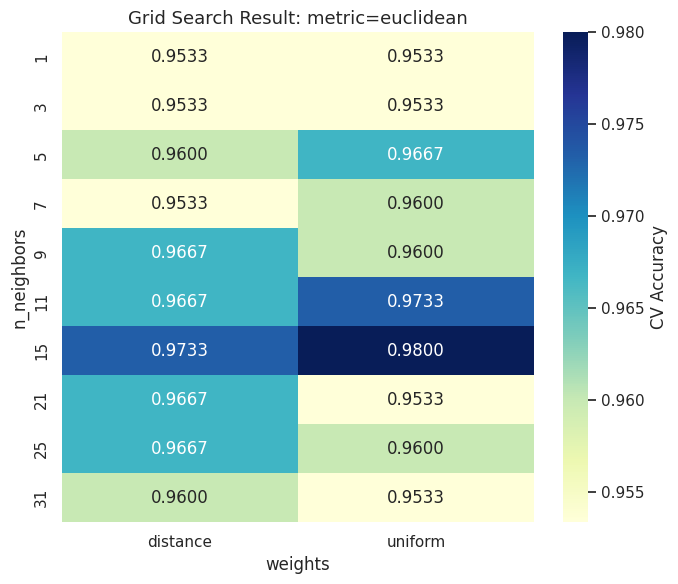

In [ ]:
# Ambil hasil detail
results = pd.DataFrame(gs.cv_results_)

# Pivot table: n_neighbors vs weights (untuk metric=euclidean)
subset = results[results['param_metric'] == 'euclidean']
pivot = subset.pivot_table(
    values='mean_test_score',
    index='param_n_neighbors',
    columns='param_weights',
)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            cbar_kws={'label': 'CV Accuracy'}, ax=ax)
ax.set_title('Grid Search Result: metric=euclidean', fontsize=13)
ax.set_xlabel('weights')
ax.set_ylabel('n_neighbors')
plt.tight_layout()
plt.show()


In [ ]:
# Top 5 kombinasi terbaik
top5 = results.nlargest(5, 'mean_test_score')[[
    'param_n_neighbors', 'param_weights', 'param_metric',
    'mean_test_score', 'std_test_score'
]]
top5.columns = ['n_neighbors', 'weights', 'metric', 'CV mean', 'CV std']
print("🏆 Top 5 Hyperparameter Combinations:")
top5.round(4).reset_index(drop=True)


🏆 Top 5 Hyperparameter Combinations:


,n_neighbors,weights,metric,CV mean,CV std
0,15,uniform,euclidean,0.9800,0.0163
1,7,distance,chebyshev,0.9800,0.0163
2,11,uniform,euclidean,0.9733,0.0249
3,15,distance,euclidean,0.9733,0.0249
4,5,distance,chebyshev,0.9733,0.0249


## F.7 LATIHAN Anda — Hitung Grid Search Random Forest

Buatlah grid search untuk Random Forest dengan hyperparameter berikut, lalu hitung total training yang dijalankan:

- `n_estimators`: [50, 100, 200, 500]
- `max_depth`: [3, 5, 10, None]
- `min_samples_split`: [2, 5, 10]
- `max_features`: ['sqrt', 'log2']
- `cv`: 10-fold

### ✏️ Jawaban Anda:


In [ ]:
# Cell latihan untuk Anda isi
# Hitung: |n_estimators| × |max_depth| × |min_samples_split| × |max_features| × cv

# Ganti ??? dengan angka Anda
n_est_size    = None    # ganti dengan angka
depth_size    = None
split_size    = None
feat_size     = None
cv_size       = None

# Uncomment 2 baris berikut ketika sudah diisi
# total = n_est_size * depth_size * split_size * feat_size
# print(f"|Grid| = {n_est_size} × {depth_size} × {split_size} × {feat_size} = {total} kombinasi")
# print(f"Total fits = {total} × {cv_size} = {total * cv_size} model dilatih")


> 💡 **Kunci Jawaban** (jangan lihat sebelum mencoba sendiri!):  
> |Grid| = 4 × 4 × 3 × 2 = **96 kombinasi**  
> Total fits = 96 × 10 = **960 model dilatih**  
> Bayangkan jika ini pada dataset besar (100 ribu baris) — bisa berjam-jam!


---

# 📝 G. Refleksi & Submit

## G.1 Lima Pertanyaan Refleksi

Jawab 5 pertanyaan berikut di cell markdown di bawah:

1. **Ruang Sampel:** Apa perbedaan konseptual antara ruang sampel eksperimen "lempar dadu" dan eksperimen "train/test split"?

2. **Aksioma Kolmogorov:** Jika saya klaim bahwa P(setosa) = 0.4, P(versicolor) = 0.4, P(virginica) = 0.3, aksioma mana yang saya langgar? Jelaskan.

3. **Set Operations:** Kapan kita menggunakan `np.setdiff1d` di dunia nyata data science? Berikan 1 contoh konkret.

4. **Kombinatorik:** Kenapa grid search Random Forest bisa sampai 960 fit sementara K-NN kita "hanya" 300 fit? Apa implikasi praktisnya untuk waktu training?

5. **Refleksi Pribadi:** Konsep mana yang paling menantang untuk Anda di Modul 2, dan strategi apa yang Anda pakai untuk memahaminya?

### ✏️ Jawaban Anda:

**1.** Pada dadu, ruang sampelnya tetap dan kecil, yaitu {1,…,6} dengan peluang sama. Pada train/test split, satu hasil eksperimen adalah satu pembagian data. Ruang sampelnya adalah semua kemungkinan pembagian n baris ke train dan test, dan ukurannya sangat besar (misalnya C(150, 30)). Hasilnya juga bergantung pada random_state.

**2.** Aksioma yang dilanggar adalah aksioma 2, P(S) = 1. Ketiga kelas saling lepas dan mencakup seluruh ruang sampel, sehingga jumlahnya harus 1. Di sini 0,4 + 0,4 + 0,3 = 1,1, melebihi 1.

**3.** Fungsi ini mencari elemen yang ada di himpunan A tetapi tidak ada di B. Contoh: mendeteksi data leakage dengan np.setdiff1d(id_test, id_train). Jika hasilnya lebih sedikit dari jumlah id_test, berarti ada baris yang sama di training dan test. Contoh lain: mencari pelanggan baru yang belum ada di daftar pelanggan lama.

**4.** Jumlah fit dihitung dengan aturan produk, yaitu perkalian jumlah opsi tiap hyperparameter dikali jumlah fold. Random Forest punya 4×4×3×2 = 96 kombinasi, dikali 10 fold = 960 fit. K-NN punya 10×2×3 = 60 kombinasi, dikali 5 fold = 300 fit. Menambah satu hyperparameter atau satu opsi akan melipatgandakan total fit. Satu fit Random Forest juga jauh lebih mahal karena melatih ratusan pohon, sehingga waktunya bisa berjam-jam pada data besar. Cara mengurangi biaya: memakai RandomizedSearchCV, memperkecil grid, mengurangi jumlah fold, dan memakai n_jobs=-1.

**5.** Konsep yang paling menantang adalah menghubungkan aksioma dan operasi himpunan dengan kode. Strategi saya adalah mencoba contoh kecil dengan itertools dan NumPy, lalu membandingkan hasil hitung manual dengan hasil program.


## G.2 Checklist Submit

Sebelum submit, pastikan:

- [ ] Semua cell code berhasil dijalankan tanpa error
- [ ] Latihan F.7 sudah diisi dengan angka yang benar
- [ ] 5 pertanyaan refleksi sudah dijawab
- [ ] Notebook di-rename: `M2-Praktikum-Iris-NamaAnda.ipynb`
- [ ] Notebook di-download dari Colab (File → Download → .ipynb)
- [ ] Notebook di-upload ke GitHub repository Anda
- [ ] Link GitHub dikumpulkan via LMS Uniska

## G.3 Push ke GitHub

**Cara paling mudah (via web):**
1. Buka repository GitHub Anda: `statistika-probabilitas-uniska`.
2. Klik folder `notebooks/`.
3. **Add file → Upload files**, drag file `M2-Praktikum-Iris-NamaAnda.ipynb`.
4. Commit message: `"Add Modul 2 praktikum: Fondasi Probabilitas + Grid Search"`.
5. Klik **Commit changes**.

---

## 🎓 Selamat!

Anda telah menyelesaikan Modul 2 dan berhasil:

✅ Memahami ruang sampel di Train/Test Split & K-Fold CV  
✅ Menerapkan 3 aksioma Kolmogorov pada data nyata  
✅ Menggunakan operasi himpunan NumPy untuk filter, deteksi leakage, dan anomaly detection  
✅ Menghitung total training grid search dengan aturan produk  
✅ Melakukan grid search K-NN dengan 300 fits

## 📚 Bacaan Lanjutan

- **VanderPlas, J.** (2023). *Python Data Science Handbook*, Chapter 5.3: Hyperparameters and Model Validation.
- **Bruce, P.** (2020). *Practical Statistics for Data Scientists*, Chapter 2: Data and Sampling Distributions.
- **Kaggle Learn** — [Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning).

## 🔮 Persiapan Modul 3

Modul 3 akan masuk ke **Bayes — Jantung AI Modern**:
- Probabilitas bersyarat P(A|B) dan Teorema Bayes
- Naive Bayes untuk klasifikasi teks (spam filter Gmail-style)
- Case study: klasifikasi review Amazon
- Quiz 1 akan menguji pemahaman Anda tentang Bayes

**Tugas Mandiri sebelum M3:**
1. Selesaikan Modul-2.ipynb, push ke GitHub.
2. Baca artikel: "The Signal and the Noise" oleh Nate Silver, Chapter 8.
3. Kaggle Learn: "Intermediate Machine Learning" (2 jam).
4. Siapkan 1 kasus di mana Anda ingin pakai Bayes untuk diskusi kelas.

---

*Notebook by: Prodi Teknik Informatika · Uniska MAB Banjarmasin · Edisi 2026*
